# **Latent Behavioral Structure and Clustering Analysis of Gen Z Wellbeing Using Exploratory Factor Analysis**

## Data Prepocessing

In [1]:
# Instal library
pip install pandas numpy matplotlib seaborn scikit-learn factor_analyzer scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=6aafdfe4b33c6ee2b65f4988977e19ac677092155b6937bf1eb14424aa22faa8
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
url = 'https://docs.google.com/spreadsheets/d/1ZUsqC2FxPMnVUargTd5ayhKgp5azTIEq0jkPLTBAn44/export?format=csv'

df = pd.read_csv(url)

df.head()

,User_Id,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,1,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,2,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,3,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,4,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,5,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [6]:
variables = [
    "Screen_Time_Hours",
    "Daily_Social_Media_Hours",
    "Night_Scrolling_Frequency",
    "Anxiety_Score",
    "Emotional_Fatigue_Score",
    "Social_Comparison_Index",
    "Sleep_Quality_Score"
]

X = df[variables]

In [8]:
# standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Factor Analysis

In [9]:
# Statistical Validity Testing
kmo_all, kmo_model = calculate_kmo(X_scaled)
print("KMO Score:", kmo_model)

chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)
print("Bartlett’s Test p-value:", p_value)

KMO Score: 0.6716413519757711
Bartlett’s Test p-value: 0.0


**Interpretasi:** The KMO value of 0.67 indicates acceptable sampling adequacy for factor analysis. While the correlation structure among variables is sufficient to proceed with EFA, the latent structure may not be strongly pronounced, suggesting moderate inter-variable relationships. Bartlett’s Test of Sphericity was highly significant (p < 0.001), indicating that the correlation matrix is not an identity matrix. This confirms the presence of sufficient inter-variable correlations to proceed with factor analysis.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


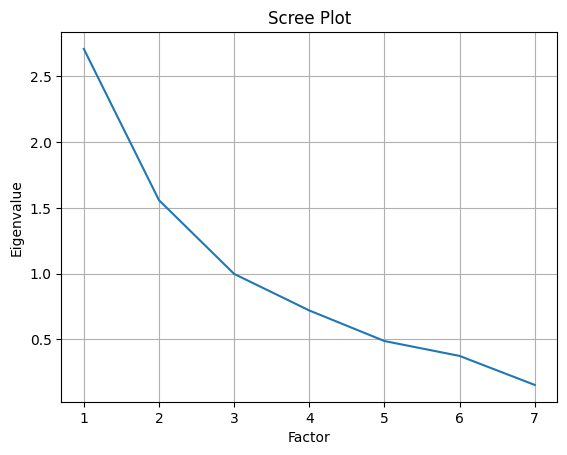

In [10]:
# Determine number of factors
fa = FactorAnalyzer(rotation=None)
fa.fit(X_scaled)

ev, v = fa.get_eigenvalues()

plt.plot(range(1, len(ev)+1), ev)
plt.title("Scree Plot")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

**Interpretasi:** The scree plot demonstrates a clear inflection point after the second factor. Based on the Kaiser criterion (eigenvalue > 1) and visual inspection of the scree curve, a two-factor solution was retained. This suggests that the behavioral variables are structured around two dominant latent dimensions.

In [11]:
# Running factor analysis
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(X_scaled)

loadings = pd.DataFrame(fa.loadings_,
                        index=variables,
                        columns=["Factor1", "Factor2"])

print(loadings)

                            Factor1   Factor2
Screen_Time_Hours          0.868401  0.046789
Daily_Social_Media_Hours   0.961797  0.017960
Night_Scrolling_Frequency -0.012227  0.182496
Anxiety_Score              0.084427  0.994522
Emotional_Fatigue_Score    0.416292  0.478506
Social_Comparison_Index    0.662807  0.010733
Sleep_Quality_Score       -0.008000 -0.361400


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Interpretasi:** Exploratory Factor Analysis revealed a two-factor structure.

Factor 1 represents Digital Engagement Intensity, characterized by high loadings on screen time, social media usage, and social comparison behavior.

Factor 2 captures Psychological Distress, dominated by anxiety, emotional fatigue, and reduced sleep quality.

This structure indicates that digital exposure and psychological wellbeing form distinct but related latent constructs.

In [12]:
# Extract factor score
factor_scores = fa.transform(X_scaled)

df["Factor1"] = factor_scores[:,0]
df["Factor2"] = factor_scores[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


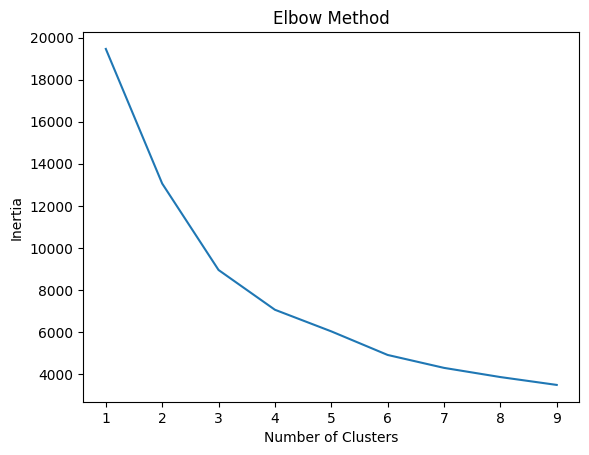

In [13]:
# CLustering elbow method
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[["Factor1", "Factor2"]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

**Interpretasi:** The Elbow Method indicated that k=3 is the optimal number of clusters, as the inertia curve showed a clear inflection point at k=3. Additional clusters beyond this point provided diminishing reductions in within-cluster variance.

In [14]:
# Final k-means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df[["Factor1", "Factor2"]])

print("Silhouette Score:",
      silhouette_score(df[["Factor1","Factor2"]], df["Cluster"]))

Silhouette Score: 0.32727991190337996


**Interpretasi:** A silhouette score of 0.327 suggests moderate but meaningful cluster separation.

In [16]:
# Cluster profiling
cluster_profile = df.groupby("Cluster")[[
    "Wellbeing_Index",
    "Factor1",
    "Factor2"
]].mean()

print(cluster_profile)

         Wellbeing_Index   Factor1   Factor2
Cluster                                     
0               2.953695 -0.165155  0.996244
1               4.639280 -0.750762 -0.682890
2               4.080302  0.978589 -0.390285


**Interpretasi:** The clustering results reveal that digital-psychological strain (Factor 1) plays a more dominant role in differentiating wellbeing levels compared to lifestyle regulation (Factor 2). Individuals with low digital strain exhibit the highest wellbeing scores, even when lifestyle regulation is not optimal. Conversely, high digital strain is associated with reduced wellbeing, regardless of moderate lifestyle behaviors.

## Visualization

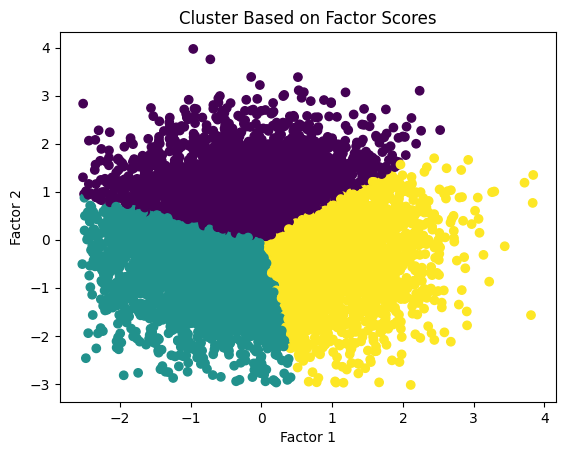

In [17]:
plt.scatter(df["Factor1"], df["Factor2"], c=df["Cluster"])
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Cluster Based on Factor Scores")
plt.show()

**Interpretasi:** Clustering based on factor scores revealed three distinct behavioral segments. The first cluster represents high digital engagement with moderate psychological stability. The second cluster reflects low digital exposure and low distress, indicating a balanced group. The third cluster captures individuals with elevated psychological distress, independent of extreme digital usage levels. This suggests that digital behavior and psychological wellbeing form multidimensional interaction patterns rather than a simple linear relationship.